# 03F — Subperiod analysis and variance decomposition

This notebook reproduces Appendix E of the current manuscript for the two subperiods:

- 1950–1979
- 1980–2023

It contains only the subperiod robustness analysis that remains after the notebook split.

## Outputs reproduced

- **Table X**: static one-period Torri / Davis–Lo / Vasicek fits by subperiod
- **Table XI**: NLL comparison of Torri / Davis–Lo / Vasicek / M2 / M1
- **Figure 9**: M1/M2 variance decomposition by subperiod

The subperiod summary statistics and Figure 1 already belong to `03A_static_one_period_models.ipynb` and are therefore not duplicated here.

## Canonical scientific conventions

- M0 is the Probit–Normal environmental null.
- M1 is M0 + Davis–Lo cumulative contagion.
- M2 is M0 + Torri threshold-type contagion.
- M2 uses the boundary-aware rule: when the fitted contagion contribution vanishes, the exact M0 boundary is selected and *u* is scientifically unidentified.
- The static Vasicek likelihood and the direct Probit–Normal M0 likelihood must be numerically equivalent within each class and period.

The numerical model functions below are extracted from the audited canonical master notebook so that this split notebook preserves the same computation before the later AntiGravity module refactor.


## 1. Setup and data selection

The public workflow may use the synthetic dataset, but manuscript regression audits are run only when the authorized real dataset is present.


In [ ]:
from pathlib import Path
import random
import math
from math import lgamma

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.optimize import minimize
from scipy.stats import norm
from numpy.polynomial.hermite import hermgauss

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
PDATA_DIR = ROOT / "pdata"
FIGURE_DIR = ROOT / "figure"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PDATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

REAL_DATA = DATA_DIR / "M_1920_2023.csv"
SYNTHETIC_DATA = DATA_DIR / "M_1920_2023_synthetic.csv"

if REAL_DATA.exists():
    DATA_FILE = REAL_DATA
    DATA_SOURCE = "REAL"
    print("=" * 72)
    print("DATA SOURCE: proprietary annual Moody's data")
    print(f"File: {DATA_FILE}")
    print("=" * 72)
elif SYNTHETIC_DATA.exists():
    DATA_FILE = SYNTHETIC_DATA
    DATA_SOURCE = "SYNTHETIC"
    print("=" * 72)
    print("DATA SOURCE: FULLY SYNTHETIC annual default data")
    print("Subperiod results will NOT reproduce the manuscript values.")
    print(f"File: {DATA_FILE}")
    print("=" * 72)
else:
    raise FileNotFoundError(
        "No annual dataset was found. Put the authorized real file at "
        "data/M_1920_2023.csv or first run 01_generate_synthetic_data.ipynb."
    )

df = pd.read_csv(DATA_FILE)

EXPECTED_COLUMNS = [
    "Year", "ALL", "D_ALL", "SG", "D_SG", "IG", "D_IG"
]
missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[EXPECTED_COLUMNS].copy()
df["Year"] = pd.to_numeric(df["Year"], errors="raise").astype(int)

for c in ["ALL", "D_ALL", "SG", "D_SG", "IG", "D_IG"]:
    df[c] = pd.to_numeric(df[c], errors="raise").astype(int)

for cls in ["ALL", "SG", "IG"]:
    valid = (
        (df[cls] > 0)
        & (df[f"D_{cls}"] >= 0)
        & (df[f"D_{cls}"] <= df[cls])
    )
    if not bool(valid.all()):
        raise ValueError(f"Invalid exposure/default counts for {cls}")

print(f"Rows: {len(df)} | Years: {df['Year'].min()}–{df['Year'].max()}")


DATA SOURCE: proprietary annual Moody's data
File: ./data/M_1920_2023.csv
Rows: 104 | Years: 1920–2023


## 2. Canonical numerical helpers


In [13]:
def log_comb(n: int, k: int) -> float:
    """log( n choose k )"""
    return lgamma(n+1) - lgamma(k+1) - lgamma(n-k+1)

def logsumexp(x: float, y: float) -> float:
    """log(exp(x)+exp(y))"""
    m = max(x, y)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.exp(x-m) + np.exp(y-m))

def logsubexp(a: float, b: float) -> float:
    """log(exp(a)-exp(b)) with a>b; otherwise -inf"""
    if b >= a:
        return -np.inf
    return a + np.log1p(-np.exp(b - a))

# The canonical Davis–Lo / Vasicek implementations use this vector form.
def logsumexp_vec(logw):
    m = np.max(logw)
    if np.isneginf(m):
        return -np.inf
    return float(m + np.log(np.sum(np.exp(logw - m))))

GH_N = 100
gh_x, gh_w = hermgauss(GH_N)


In [14]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def softplus(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)

def inv_softplus(s):
    s = float(s)
    if s <= 0:
        raise ValueError("softplus inverse requires s > 0")
    return s + np.log(-np.expm1(-s))

def _clean_nh(series_n, series_h):
    tmp = pd.DataFrame({
        "n": series_n.to_numpy(dtype=int),
        "h": series_h.to_numpy(dtype=int),
    })
    tmp = tmp[(tmp["n"] > 0) & (tmp["h"] >= 0) & (tmp["h"] <= tmp["n"])].copy()
    return tmp

def make_grouped_nh(series_n, series_h):
    tmp = _clean_nh(series_n, series_h)
    g = tmp.value_counts().reset_index(name="cnt")
    n_arr = g["n"].to_numpy(dtype=int)
    h_arr = g["h"].to_numpy(dtype=int)
    c_arr = g["cnt"].to_numpy(dtype=int)
    return n_arr, h_arr, c_arr

def _clean_nL(df, key):
    n_vals = df[key].astype(int).to_numpy()
    L_vals = df["D_" + key].astype(int).to_numpy()
    mask = (
        (n_vals > 0) &
        (L_vals >= 0) &
        (L_vals <= n_vals) &
        np.isfinite(n_vals) &
        np.isfinite(L_vals)
    )
    return n_vals[mask].astype(int), L_vals[mask].astype(int)

def scaled_counts(n_vals, L_vals, nbar):
    n_vals = np.asarray(n_vals, dtype=float)
    L_vals = np.asarray(L_vals, dtype=float)
    Ls = np.rint(L_vals * (float(nbar) / n_vals)).astype(int)
    Ls = np.maximum(Ls, 0)
    return Ls

def gh_normal_weights(mu, sigma, GH_N):
    x, w = hermgauss(int(GH_N))
    y = mu + math.sqrt(2.0) * sigma * x
    wn = w / math.sqrt(math.pi)
    wn = wn / np.sum(wn)
    return y, wn

def aggregate_m_q_to_rho(m, q):
    den = m * (1.0 - m)
    if den <= 1e-15:
        return float("nan")
    return (q - m * m) / den

def torri_m_q_for_n(n, p, u, v):
    b = (1.0 - p) * (1.0 - u)
    s = 1.0 - p * v
    a = p * (1.0 - v)
    m = p + b * (1.0 - s**(n - 1)) if n >= 1 else 0.0
    q_pair = (p + b)**2 - b * (2.0 * a + b) * (s**(n - 2)) if n >= 2 else m * m
    return float(m), float(q_pair)

def ld_m_q_for_n(n, p, q_param):
    # m = 1 - (1-p)(1-qp)^(n-1)
    m = 1.0 - (1.0 - p) * (1.0 - q_param * p)**(n - 1) if n >= 1 else 0.0
    if n < 2:
        return float(m), float(m*m)

    # cov formula (from your m_rho_LD docstring)
    termA = (1.0 - 2.0*p*q_param + p*(q_param**2))**(n - 2)
    termB = (1.0 - p*q_param)**(2*(n - 1))
    cov = (1.0 - p)**2 * (termA - termB)

    # q = m^2 + cov
    q_pair = m*m + cov
    return float(m), float(q_pair)


## 3. Static one-period likelihoods

These are the same static fitting routines used in the canonical analysis. They are retained here because Table X is explicitly a subperiod re-fit, not a reuse of the full-sample estimates.


In [15]:
def log_pmf_Torri(n: int, h: int, p: float, u: float, v: float) -> float:
    # constraints (p strictly inside to avoid log(0) issues in bc=1-p)
    if not (0.0 < p < 1.0 and 0.0 <= u <= 1.0 and 0.0 <= v <= 1.0):
        return -np.inf
    if not (0 <= h <= n):
        return -np.inf

    a = p*(1.0 - v)
    b = (1.0 - p)*(1.0 - u)
    c = (1.0 - p)*u
    bc = b + c  # = 1-p

    # --- term0 = a^h * (b+c)^(n-h) ---
    # log term0
    if h > 0:
        if a <= 0.0:
            t0 = -np.inf
        else:
            t0 = h*math.log(a) + (n-h)*math.log(bc)
    else:
        # a^0 = 1
        t0 = (n-h)*math.log(bc)

    # --- term1 = ((p+b)^h - (a+b)^h) * c^(n-h) ---
    pb = p + b
    ab = a + b

    if h == 0:
        t1 = -np.inf
    else:
        # if v=0 -> a=p -> pb==ab -> difference 0
        if pb <= 0.0 or ab <= 0.0:
            t1 = -np.inf
        else:
            lp = h*math.log(pb)
            la = h*math.log(ab)

            # stable log(exp(lp)-exp(la)) (requires lp>la)
            diff_log = logsubexp(lp, la)
            if diff_log == -np.inf:
                t1 = -np.inf
            else:
                if (n-h) > 0:
                    if c <= 0.0:
                        t1 = -np.inf
                    else:
                        t1 = diff_log + (n-h)*math.log(c)
                else:
                    t1 = diff_log

    # combine
    inner = logsumexp(t0, t1)
    if inner == -np.inf:
        return -np.inf

    return log_comb(n, h) + inner

def fit_one_Torri(series_n, series_h, x0=None, maxiter=5000):
    data = np.c_[series_n.to_numpy(dtype=int), series_h.to_numpy(dtype=int)]

    def neg_ll_torri(theta):
        # unconstrained -> (0,1) via sigmoid
        p = 1.0/(1.0 + np.exp(-theta[0]))
        u = 1.0/(1.0 + np.exp(-theta[1]))
        v = 1.0/(1.0 + np.exp(-theta[2]))

        ll = 0.0
        for n, h in data:
            lp = log_pmf_Torri(int(n), int(h), float(p), float(u), float(v))
            if not np.isfinite(lp):
                return 1e100
            ll += lp
        return -ll

    # initial guess (logit)
    if x0 is None:
        x0 = np.array([
            math.log(0.01/0.99),  # p ~ 1%
            math.log(0.9/0.1),    # u ~ 0.9
            math.log(0.1/0.9),    # v ~ 0.1
        ], dtype=float)

    res = minimize(neg_ll_torri, x0, method="Nelder-Mead", options={"maxiter": maxiter})

    th = res.x
    p = 1.0/(1.0 + np.exp(-th[0]))
    u = 1.0/(1.0 + np.exp(-th[1]))
    v = 1.0/(1.0 + np.exp(-th[2]))
    return {
        "p": float(p), "u": float(u), "v": float(v),
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
    }

def log_pmf_LD_1pt(n, h, p, q):
    """
    LD mixture:
      K ~ Bin(n,p)
      L|K=k = k + Bin(n-k, r_k),  r_k = 1 - (1-q)^k
    Return log P(L=h) by summing over k=0..h
    """
    if not (0 <= h <= n):
        return -np.inf

    # numerical guards
    eps = 1e-15
    p = float(np.clip(p, eps, 1.0 - eps))
    q = float(np.clip(q, eps, 1.0 - eps))

    log_p  = math.log(p)
    log_1p = math.log1p(-p)
    log_1q = math.log1p(-q)

    terms = np.full(h+1, -np.inf, dtype=float)

    for k in range(0, h+1):
        t = h - k
        nk = n - k
        if t < 0 or t > nk:
            continue

        # log P(K=k)
        log_pk = log_comb(n, k) + k*log_p + (n-k)*log_1p

        # r_k = 1 - (1-q)^k  (stable)
        if k == 0:
            if t != 0:
                continue
            log_bin = 0.0
        else:
            rk = -math.expm1(k * log_1q)  # stable 1-(1-q)^k
            # handle extreme rk
            if rk <= 0.0:
                if t != 0:
                    continue
                log_bin = 0.0
            elif rk >= 1.0:
                if t != nk:
                    continue
                log_bin = 0.0
            else:
                log_r  = math.log(rk)
                log_1r = math.log1p(-rk)
                log_bin = log_comb(nk, t) + t*log_r + (nk-t)*log_1r

        terms[k] = log_pk + log_bin

    return logsumexp_vec(terms)

def fit_one_LD(series_n, series_h):
    tmp = pd.DataFrame({"n": series_n.to_numpy(dtype=int),
                        "h": series_h.to_numpy(dtype=int)})
    g = tmp.value_counts().reset_index(name="cnt")
    n_arr = g["n"].to_numpy(dtype=int)
    h_arr = g["h"].to_numpy(dtype=int)
    c_arr = g["cnt"].to_numpy(dtype=int)

    def neg_ll_ld(theta):
        p = 1/(1+np.exp(-theta[0]))
        q = 1/(1+np.exp(-theta[1]))

        ll = 0.0
        for n, h, c in zip(n_arr, h_arr, c_arr):
            lp = log_pmf_LD_1pt(int(n), int(h), float(p), float(q))
            if not np.isfinite(lp):
                return 1e100
            ll += c * lp
        return -ll

    x0 = np.array([math.log(0.01/0.99), math.log(0.02/0.98)])
    res = minimize(neg_ll_ld, x0, method="Nelder-Mead", options={"maxiter":8000})

    th = res.x
    p = 1/(1+np.exp(-th[0]))
    q = 1/(1+np.exp(-th[1]))
    return {
        "p": float(p), "q": float(q),
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
    }

def log_pmf_Vas_1pt(n: int, h: int, p: float, rho_A: float) -> float:
    if not (0 <= h <= n):
        return -np.inf

    eps = 1e-15
    p = float(np.clip(p, eps, 1.0 - eps))
    rho_A = float(np.clip(rho_A, eps, 1.0 - 1e-12))

    a  = norm.ppf(p)
    sr = math.sqrt(rho_A)
    tr = math.sqrt(1.0 - rho_A)

    logC = log_comb(n, h)

    # guard invalid GH weights (should be fine up to ~200, but harmless)
    mask = np.isfinite(gh_w) & (gh_w > 0) & np.isfinite(gh_x)
    x = gh_x[mask]
    w = gh_w[mask]
    if len(w) == 0:
        return -np.inf

    log_terms = np.empty(len(w), dtype=float)

    for i, (xi, wi) in enumerate(zip(x, w)):
        z  = math.sqrt(2.0) * float(xi)
        pi = norm.cdf((a - sr*z) / tr)
        pi = float(np.clip(pi, eps, 1.0 - eps))

        log_bin = logC + h*math.log(pi) + (n-h)*math.log1p(-pi)
        log_terms[i] = math.log(float(wi)) + log_bin

    return logsumexp_vec(log_terms) - 0.5*math.log(math.pi)

def fit_one_Vas(series_n, series_h, x0=None, maxiter=8000):
    tmp = pd.DataFrame({
        "n": series_n.to_numpy(dtype=int),
        "h": series_h.to_numpy(dtype=int),
    })
    g = tmp.value_counts().reset_index(name="cnt")
    n_arr = g["n"].to_numpy(dtype=int)
    h_arr = g["h"].to_numpy(dtype=int)
    c_arr = g["cnt"].to_numpy(dtype=int)

    def neg_ll_vas(theta):
        p     = 1.0/(1.0 + np.exp(-theta[0]))
        rho_A = 1.0/(1.0 + np.exp(-theta[1]))

        ll = 0.0
        for n, h, c in zip(n_arr, h_arr, c_arr):
            lp = log_pmf_Vas_1pt(int(n), int(h), float(p), float(rho_A))
            if not np.isfinite(lp):
                return 1e100
            ll += int(c) * lp
        return -ll

    if x0 is None:
        x0 = np.array([math.log(0.01/0.99), math.log(0.05/0.95)], dtype=float)

    res = minimize(neg_ll_vas, x0, method="Nelder-Mead", options={"maxiter": maxiter})

    th = res.x
    p     = 1.0/(1.0 + np.exp(-th[0]))
    rho_A = 1.0/(1.0 + np.exp(-th[1]))

    return {
        "p": float(p),
        "rho_A": float(rho_A),
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
        "GH_N": int(GH_N),
    }


## 4. Environmental M0/M1/M2 likelihoods

M0 is fitted directly as a Probit–Normal binomial mixture. M1 and M2 are then re-fitted separately in each subperiod.


In [16]:
def log_pmf_pn_LD_1pt(n, h, mu, sigma, q, gh_x, gh_w):
    """
    Log probability for one observation under the
    Probit–Normal mixture Davis–Lo model.

    Model:
        y ~ N(mu, sigma^2)
        p = Phi(y)
        L | n, p, q ~ Davis-Lo(n, p, q)

    Hence,

        P(L=h | n, mu, sigma, q)
        = integral P_LD(L=h | n, p=Phi(y), q)
                   N(y | mu, sigma^2) dy

    approximated by Gauss-Hermite quadrature as

        (1/sqrt(pi)) * sum_j
        w_j * P_LD(
            h | n,
            Phi(mu + sqrt(2)*sigma*x_j),
            q
        ).
    """
    if not (0 <= h <= n):
        return -np.inf

    if sigma <= 0:
        return -np.inf

    if not (0.0 < q < 1.0):
        return -np.inf

    log_terms = np.full(len(gh_w), -np.inf, dtype=float)

    for j, (xj, wj) in enumerate(zip(gh_x, gh_w)):
        y = mu + math.sqrt(2.0) * sigma * float(xj)
        p = float(norm.cdf(y))

        # Protect against exact 0 or 1.
        p = float(np.clip(p, 1e-15, 1.0 - 1e-15))

        lp = log_pmf_LD_1pt(
            int(n),
            int(h),
            p,
            float(q),
        )

        if np.isfinite(lp):
            log_terms[j] = math.log(float(wj)) + lp

    out = (
        logsumexp_vec(log_terms)
        - 0.5 * math.log(math.pi)
    )

    return float(out)

def neg_ll_pn_LD(theta, n_arr, h_arr, c_arr, gh_x, gh_w):
    """
    Negative log-likelihood for the
    Probit–Normal mixture Davis–Lo model.

    Unconstrained parameterization:

        theta = (mu_raw, sigma_raw, q_raw)

        mu    = mu_raw
        sigma = softplus(sigma_raw)
        q     = sigmoid(q_raw)
    """
    mu = float(theta[0])
    sigma = float(softplus(theta[1]))
    q = float(sigmoid(theta[2]))

    ll = 0.0

    for n, h, c in zip(n_arr, h_arr, c_arr):
        lp = log_pmf_pn_LD_1pt(
            int(n),
            int(h),
            mu,
            sigma,
            q,
            gh_x,
            gh_w,
        )

        if not np.isfinite(lp):
            return 1e100

        ll += int(c) * lp

    return float(-ll)

def fit_one_pn_LD(
    series_n,
    series_h,
    GH_N=20,
    x0=None,
    maxiter=5000,
    method="Nelder-Mead",
):
    """
    Maximum-likelihood fit of the
    Probit–Normal environmental mixture
    with Davis–Lo cumulative contagion.

    Parameters
    ----------
    series_n, series_h : pandas Series
        Observed yearly exposure n_t and default count L_t.

    GH_N : int
        Number of Gauss-Hermite quadrature nodes.

    x0 : array-like or None
        Initial values for the unconstrained parameters

            (mu_raw, sigma_raw, q_raw).

    maxiter : int
        Maximum number of optimizer iterations.

    method : str
        scipy.optimize.minimize method.
    """
    n_arr, h_arr, c_arr = make_grouped_nh(
        series_n,
        series_h,
    )

    gh_x, gh_w = hermgauss(GH_N)

    # Initial values based on the exposure-weighted default rate.
    m_hat = float(
        series_h.sum() / series_n.sum()
    )

    mu0 = float(
        norm.ppf(
            np.clip(
                m_hat,
                1e-6,
                1.0 - 1e-6,
            )
        )
    )

    sigma0 = 0.5
    q0 = 0.01

    if x0 is None:
        x0 = np.array(
            [
                mu0,
                inv_softplus(sigma0),
                math.log(q0 / (1.0 - q0)),
            ],
            dtype=float,
        )

    res = minimize(
        neg_ll_pn_LD,
        x0=x0,
        args=(
            n_arr,
            h_arr,
            c_arr,
            gh_x,
            gh_w,
        ),
        method=method,
        options={
            "maxiter": maxiter,
        },
    )

    mu_hat = float(res.x[0])
    sigma_hat = float(
        softplus(res.x[1])
    )
    q_hat = float(
        sigmoid(res.x[2])
    )

    return {
        "mu": mu_hat,
        "sigma": sigma_hat,
        "q": q_hat,
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
        "GH_N": int(GH_N),
        "m_hat_init": m_hat,
    }


In [17]:
V_ZERO_TOL = 1e-10
NLL_EQUAL_TOL = 1e-6


def log_pmf_pn_Torri_1pt(
    n,
    h,
    mu,
    sigma,
    u,
    v,
    gh_x,
    gh_w,
):
    """
    Log probability under:

        y ~ N(mu, sigma^2)
        p = Phi(y)
        L | n, p, u, v ~ Torri(n, p, u, v)

    integrated over y using Gauss-Hermite quadrature.
    """

    if not (0 <= h <= n):
        return -np.inf

    if sigma <= 0:
        return -np.inf

    if not (
        0.0 <= u <= 1.0
        and 0.0 <= v <= 1.0
    ):
        return -np.inf

    log_terms = np.full(
        len(gh_w),
        -np.inf,
        dtype=float,
    )

    for j, (xj, wj) in enumerate(zip(gh_x, gh_w)):

        y = (
            mu
            + math.sqrt(2.0)
            * sigma
            * float(xj)
        )

        p = float(norm.cdf(y))

        p = float(
            np.clip(
                p,
                1e-15,
                1.0 - 1e-15,
            )
        )

        lp = log_pmf_Torri(
            int(n),
            int(h),
            p,
            float(u),
            float(v),
        )

        if np.isfinite(lp):
            log_terms[j] = (
                math.log(float(wj))
                + lp
            )

    return float(
        logsumexp_vec(log_terms)
        - 0.5 * math.log(math.pi)
    )

def neg_ll_pn_Torri(
    theta,
    n_arr,
    h_arr,
    c_arr,
    gh_x,
    gh_w,
):
    """
    theta = (mu_raw, sigma_raw, u_raw, v_raw)

        mu    = mu_raw
        sigma = softplus(sigma_raw)
        u     = sigmoid(u_raw)
        v     = sigmoid(v_raw)
    """

    mu = float(theta[0])
    sigma = float(softplus(theta[1]))
    u = float(sigmoid(theta[2]))
    v = float(sigmoid(theta[3]))

    ll = 0.0

    for n, h, c in zip(
        n_arr,
        h_arr,
        c_arr,
    ):

        lp = log_pmf_pn_Torri_1pt(
            int(n),
            int(h),
            mu,
            sigma,
            u,
            v,
            gh_x,
            gh_w,
        )

        if not np.isfinite(lp):
            return 1e100

        ll += int(c) * lp

    return float(-ll)

def neg_ll_pn_null(
    theta,
    n_arr,
    h_arr,
    c_arr,
    GH_N,
):
    """
    Exact M0 Probit-Normal likelihood:

        y_t ~ N(mu, sigma^2)
        p_t = Phi(y_t)
        L_t | n_t, p_t ~ Binomial(n_t, p_t)

    theta = (mu, log_sigma)
    """

    mu = float(theta[0])
    sigma = float(np.exp(theta[1]))

    gh_x, gh_w = hermgauss(
        int(GH_N)
    )

    y_nodes = (
        mu
        + math.sqrt(2.0)
        * sigma
        * gh_x
    )

    p_nodes = norm.cdf(
        y_nodes
    )

    p_nodes = np.clip(
        p_nodes,
        1e-15,
        1.0 - 1e-15,
    )

    w_nodes = (
        gh_w
        / math.sqrt(math.pi)
    )

    w_nodes = (
        w_nodes
        / np.sum(w_nodes)
    )

    log_w = np.log(
        w_nodes
    )

    log_p = np.log(
        p_nodes
    )

    log_1mp = np.log1p(
        -p_nodes
    )

    total_nll = 0.0

    for n, h, c in zip(
        n_arr,
        h_arr,
        c_arr,
    ):

        log_c = (
            math.lgamma(int(n) + 1)
            - math.lgamma(int(h) + 1)
            - math.lgamma(int(n) - int(h) + 1)
        )

        log_terms = (
            log_c
            + int(h) * log_p
            + (int(n) - int(h))
            * log_1mp
        )

        lp = logsumexp_vec(
            log_w
            + log_terms
        )

        if not np.isfinite(lp):
            return 1e100

        total_nll -= (
            int(c)
            * lp
        )

    return float(
        total_nll
    )

def fit_pn_null_from_grouped(
    n_arr,
    h_arr,
    c_arr,
    GH_N=100,
):
    """
    Direct M0 Probit-Normal MLE.

    Robust multi-start version.

    For each candidate sigma0, choose mu0 so that

        E[Phi(Y)] = Phi(mu0 / sqrt(1 + sigma0^2))

    approximately matches the empirical aggregate
    default rate.
    """

    n_arr = np.asarray(
        n_arr,
        dtype=int,
    )

    h_arr = np.asarray(
        h_arr,
        dtype=int,
    )

    c_arr = np.asarray(
        c_arr,
        dtype=int,
    )

    p_hat = float(
        np.sum(
            h_arr * c_arr
        )
        /
        np.sum(
            n_arr * c_arr
        )
    )

    z_hat = float(
        norm.ppf(
            np.clip(
                p_hat,
                1e-8,
                1.0 - 1e-8,
            )
        )
    )

    sigma_starts = [
        0.05,
        0.10,
        0.20,
        0.30,
        0.50,
        0.80,
        1.20,
    ]

    best_res = None
    best_start_sigma = None

    for sigma0 in sigma_starts:

        mu0 = float(
            z_hat
            * np.sqrt(
                1.0 + sigma0**2
            )
        )

        res = minimize(
            neg_ll_pn_null,
            x0=np.array(
                [
                    mu0,
                    math.log(sigma0),
                ],
                dtype=float,
            ),
            args=(
                n_arr,
                h_arr,
                c_arr,
                GH_N,
            ),
            method="L-BFGS-B",
        )

        if (
            np.isfinite(res.fun)
            and (
                best_res is None
                or float(res.fun) < float(best_res.fun)
            )
        ):
            best_res = res
            best_start_sigma = sigma0

    if best_res is None:
        raise RuntimeError(
            "M0 Probit-Normal multi-start fit failed."
        )

    return {
        "mu": float(
            best_res.x[0]
        ),

        "sigma": float(
            np.exp(
                best_res.x[1]
            )
        ),

        "nll": float(
            best_res.fun
        ),

        "success": bool(
            best_res.success
        ),

        "nit": int(
            best_res.nit
        ),

        "message": str(
            best_res.message
        ),

        "GH_N": int(
            GH_N
        ),

        "n_starts": int(
            len(sigma_starts)
        ),

        "best_start_sigma": float(
            best_start_sigma
        ),
    }

def fit_one_pn_Torri(
    series_n,
    series_h,
    GH_N=100,
    x0=None,
    maxiter=8000,
    method="Nelder-Mead",
    v_zero_tol=V_ZERO_TOL,
    nll_equal_tol=NLL_EQUAL_TOL,
):
    """
    Fit M2 and compare it with its exact M0 boundary.

    Procedure:

      1. Fit the ordinary four-parameter M2.
      2. Fit the exact Probit-Normal M0.
      3. Select M0 boundary if:

             v_raw < v_zero_tol

         or if M2 fails to improve NLL relative to M0
         beyond numerical tolerance.

      4. Otherwise retain the interior M2 solution.

    On the boundary:
        v = 0 exactly,
        u is unidentified.
    """

    n_arr, h_arr, c_arr = make_grouped_nh(
        series_n,
        series_h,
    )

    gh_x, gh_w = hermgauss(
        GH_N
    )

    # --------------------------------------------------------
    # Initial values for raw M2
    # --------------------------------------------------------

    m_hat = float(
        series_h.sum()
        / series_n.sum()
    )

    mu0 = float(
        norm.ppf(
            np.clip(
                m_hat,
                1e-6,
                1.0 - 1e-6,
            )
        )
    )

    sigma0 = 0.5
    u0 = 0.9
    v0 = 0.01

    if x0 is None:

        x0 = np.array(
            [
                mu0,
                inv_softplus(
                    sigma0
                ),
                math.log(
                    u0
                    / (1.0 - u0)
                ),
                math.log(
                    v0
                    / (1.0 - v0)
                ),
            ],
            dtype=float,
        )

    # ========================================================
    # Step 1: raw four-parameter M2 fit
    # ========================================================

    res_raw = minimize(
        neg_ll_pn_Torri,
        x0=x0,
        args=(
            n_arr,
            h_arr,
            c_arr,
            gh_x,
            gh_w,
        ),
        method=method,
        options={
            "maxiter": maxiter,
        },
    )

    mu_raw = float(
        res_raw.x[0]
    )

    sigma_raw = float(
        softplus(
            res_raw.x[1]
        )
    )

    u_raw = float(
        sigmoid(
            res_raw.x[2]
        )
    )

    v_raw = float(
        sigmoid(
            res_raw.x[3]
        )
    )

    nll_raw = float(
        res_raw.fun
    )

    # ========================================================
    # Step 2: exact M0 Probit-Normal boundary
    # ========================================================

    fit_m0 = fit_pn_null_from_grouped(
        n_arr,
        h_arr,
        c_arr,
        GH_N=GH_N,
    )

    mu_m0 = float(
        fit_m0["mu"]
    )

    sigma_m0 = float(
        fit_m0["sigma"]
    )

    nll_m0 = float(
        fit_m0["nll"]
    )

    # ========================================================
    # Step 3: boundary decision
    # ========================================================

    boundary_by_v = (
        v_raw
        < v_zero_tol
    )

    boundary_by_nll = (
        nll_raw
        >= nll_m0
        - nll_equal_tol
    )

    choose_boundary = (
        boundary_by_v
        or boundary_by_nll
    )

    # ========================================================
    # Exact M0 boundary solution
    # ========================================================

    if choose_boundary:

        return {
            "mu": mu_m0,
            "sigma": sigma_m0,

            # u is scientifically unidentified at v=0.
            "u": np.nan,

            # Numerical placeholder only.
            "u_eval": 0.5,

            "v": 0.0,

            "nll": nll_m0,

            "boundary": True,
            "solution": "M0 boundary (v=0)",
            "u_identified": False,

            # Diagnostics
            "mu_raw": mu_raw,
            "sigma_raw": sigma_raw,
            "u_raw": u_raw,
            "v_raw": v_raw,
            "nll_raw": nll_raw,
            "nll_m0": nll_m0,

            "boundary_by_v": bool(
                boundary_by_v
            ),

            "boundary_by_nll": bool(
                boundary_by_nll
            ),

            "success": bool(
                fit_m0["success"]
            ),

            "nit": int(
                fit_m0["nit"]
            ),

            "message": str(
                fit_m0["message"]
            ),

            "GH_N": int(
                GH_N
            ),

            "m_hat_init": m_hat,
        }

    # ========================================================
    # Genuine interior M2
    # ========================================================

    return {
        "mu": mu_raw,
        "sigma": sigma_raw,
        "u": u_raw,
        "u_eval": u_raw,
        "v": v_raw,

        "nll": nll_raw,

        "boundary": False,
        "solution": "interior M2",
        "u_identified": True,

        # Diagnostics
        "mu_raw": mu_raw,
        "sigma_raw": sigma_raw,
        "u_raw": u_raw,
        "v_raw": v_raw,
        "nll_raw": nll_raw,
        "nll_m0": nll_m0,

        "boundary_by_v": False,
        "boundary_by_nll": False,

        "success": bool(
            res_raw.success
        ),

        "nit": int(
            res_raw.nit
        ),

        "message": str(
            res_raw.message
        ),

        "GH_N": int(
            GH_N
        ),

        "m_hat_init": m_hat,
    }


## 5. Variance-decomposition functions

For fixed *nbar*, the model-implied annual variance is decomposed into:

- conditional binomial variation (`iid` in the historical figure label),
- contagion,
- cross-year fluctuation in the latent default probability *p_t*.

The figure normalizes each component by the empirical variance of the fixed-*nbar* scaled default counts.


In [18]:
def variance_decomp_pn_ld_fixed_nbar(
    df,
    NBAR,
    fits_pn_ld,
    keys=("ALL", "SG", "IG"),
):
    """
    Variance decomposition for M1
    (Probit–Normal environmental mixture + Davis–Lo contagion)
    at a fixed representative exposure nbar.

    For each class,

        Var(L)
          = Var_iid
            + Var_contagion
            + Var_pt,

    where

        Var_iid
          = E[nbar * m_t * (1 - m_t)],

        Var_contagion
          = E[
                nbar * (nbar - 1)
                * (q_t - m_t^2)
              ],

        Var_pt
          = Var(nbar * m_t).

    Here p_t is integrated over the fitted Probit–Normal
    environmental distribution using Gauss-Hermite quadrature.
    """
    rows = []

    for key in keys:

        # --------------------------------------------------------
        # Representative fixed exposure and data-side quantities
        # --------------------------------------------------------
        nbar = int(NBAR[key])

        n_vals, L_vals = _clean_nL(
            df,
            key,
        )

        L_scaled = scaled_counts(
            n_vals,
            L_vals,
            nbar,
        )

        var_data_scaled = (
            float(np.var(L_scaled, ddof=1))
            if len(L_scaled) >= 2
            else np.nan
        )

        m_hat_data = float(
            np.sum(L_vals) / np.sum(n_vals)
        )

        var_iid_data_scaled = float(
            nbar
            * m_hat_data
            * (1.0 - m_hat_data)
        )

        var_corr_data_scaled = (
            var_data_scaled
            - var_iid_data_scaled
            if np.isfinite(var_data_scaled)
            else np.nan
        )

        # --------------------------------------------------------
        # Fitted M1 parameters
        # --------------------------------------------------------
        mu = float(
            fits_pn_ld[key]["mu"]
        )

        sigma = float(
            fits_pn_ld[key]["sigma"]
        )

        q_param = float(
            fits_pn_ld[key]["q"]
        )

        GH_N = int(
            fits_pn_ld[key]["GH_N"]
        )

        # --------------------------------------------------------
        # Gauss-Hermite quadrature for
        #
        #   y_t ~ N(mu, sigma^2)
        #   p_t = Phi(y_t)
        # --------------------------------------------------------
        y_nodes, w_nodes = gh_normal_weights(
            mu,
            sigma,
            GH_N,
        )

        p_nodes = norm.cdf(y_nodes)

        p_nodes = np.clip(
            p_nodes,
            1e-15,
            1.0 - 1e-15,
        )

        # --------------------------------------------------------
        # Conditional Davis–Lo moments at fixed nbar
        #
        #   m_t = E[L_t | p_t] / nbar
        #   q_t = E[Z_i Z_j | p_t]
        # --------------------------------------------------------
        m_nodes = np.empty_like(
            p_nodes,
            dtype=float,
        )

        q_nodes = np.empty_like(
            p_nodes,
            dtype=float,
        )

        for j, p_t in enumerate(p_nodes):

            m_t, q_t = ld_m_q_for_n(
                nbar,
                float(p_t),
                q_param,
            )

            m_nodes[j] = m_t
            q_nodes[j] = q_t

        # --------------------------------------------------------
        # Model-implied variance decomposition
        # --------------------------------------------------------

        # Conditional Bernoulli/iid component
        var_iid_model = float(
            np.sum(
                w_nodes
                * (
                    nbar
                    * m_nodes
                    * (1.0 - m_nodes)
                )
            )
        )

        # Davis–Lo cumulative-contagion component
        var_infect_model = float(
            np.sum(
                w_nodes
                * (
                    nbar
                    * (nbar - 1)
                    * (
                        q_nodes
                        - m_nodes**2
                    )
                )
            )
        )

        # Environmental p_t-fluctuation component
        mean_nbar_m = float(
            np.sum(
                w_nodes
                * (nbar * m_nodes)
            )
        )

        var_pt_model = float(
            np.sum(
                w_nodes
                * (nbar * m_nodes)**2
            )
            - mean_nbar_m**2
        )

        var_model_total = (
            var_iid_model
            + var_infect_model
            + var_pt_model
        )

        # --------------------------------------------------------
        # Additional model summaries
        # --------------------------------------------------------
        m_bar = float(
            np.sum(
                w_nodes * m_nodes
            )
        )

        q_bar = float(
            np.sum(
                w_nodes * q_nodes
            )
        )

        denom_rho = (
            m_bar
            * (1.0 - m_bar)
        )

        rho_bar = (
            (q_bar - m_bar**2)
            / denom_rho
            if denom_rho > 1e-15
            else np.nan
        )

        # --------------------------------------------------------
        # Store results
        # --------------------------------------------------------
        rows.append(
            {
                "class": key,
                "nbar": nbar,
                "mu": mu,
                "sigma": sigma,
                "q_param": q_param,
                "GH_N": GH_N,

                # Data-side quantities
                "Var_data_scaled": var_data_scaled,
                "m_hat_data": m_hat_data,
                "Var_iid_data_scaled": var_iid_data_scaled,
                "Var_corr_data_scaled": var_corr_data_scaled,

                # Model-implied summaries
                "m_bar_model": m_bar,
                "q_bar_model": q_bar,
                "rho_bar_model": rho_bar,

                # Variance components
                "Var_iid_model": var_iid_model,
                "Var_infect_model": var_infect_model,
                "Var_pt_model": var_pt_model,
                "Var_model_total": var_model_total,

                # Shares within model-implied variance
                "Share_iid_within_model": (
                    var_iid_model / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                "Share_infect_within_model": (
                    var_infect_model / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                "Share_pt_within_model": (
                    var_pt_model / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                # Components relative to empirical scaled variance
                "Infect_over_VarData": (
                    var_infect_model / var_data_scaled
                    if (
                        np.isfinite(var_data_scaled)
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),

                "Pt_over_VarData": (
                    var_pt_model / var_data_scaled
                    if (
                        np.isfinite(var_data_scaled)
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),

                "Iid_over_VarData": (
                    var_iid_model / var_data_scaled
                    if (
                        np.isfinite(var_data_scaled)
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(rows)


In [19]:
def variance_decomp_pn_torri_fixed_nbar(
    df,
    NBAR,
    fits_pn_torri,
    keys=("ALL", "SG", "IG"),
):
    """
    Variance decomposition for M2
    (Probit-Normal environmental mixture + Torri contagion)
    at fixed representative exposure nbar.

    Interior M2:
        Torri conditional moments are used.

    Exact v=0 boundary:
        M2 is identical to M0, so

            m_t = p_t
            q_t = p_t^2

        and the contagion variance is exactly zero.
    """

    rows = []

    for key in keys:

        # ====================================================
        # Fixed representative exposure
        # ====================================================

        nbar = int(
            NBAR[key]
        )

        # ====================================================
        # Data-side quantities under fixed-nbar scaling
        # ====================================================

        n_vals, L_vals = _clean_nL(
            df,
            key,
        )

        L_scaled = scaled_counts(
            n_vals,
            L_vals,
            nbar,
        )

        var_data_scaled = (
            float(
                np.var(
                    L_scaled,
                    ddof=1,
                )
            )
            if len(L_scaled) >= 2
            else np.nan
        )

        m_hat_data = float(
            np.sum(L_vals)
            / np.sum(n_vals)
        )

        var_iid_data_scaled = float(
            nbar
            * m_hat_data
            * (1.0 - m_hat_data)
        )

        var_corr_data_scaled = (
            var_data_scaled
            - var_iid_data_scaled
            if np.isfinite(
                var_data_scaled
            )
            else np.nan
        )

        # ====================================================
        # Fitted M2 parameters
        # ====================================================

        fit = fits_pn_torri[key]

        mu = float(
            fit["mu"]
        )

        sigma = float(
            fit["sigma"]
        )

        # u is NaN at the exact v=0 boundary.
        u = float(
            fit["u"]
        )

        # u_eval is only required by numerical Torri routines.
        u_eval = float(
            fit["u_eval"]
        )

        v = float(
            fit["v"]
        )

        boundary = bool(
            fit["boundary"]
        )

        u_identified = bool(
            fit["u_identified"]
        )

        GH_N = int(
            fit["GH_N"]
        )

        # ====================================================
        # Gauss-Hermite quadrature
        #
        #   y_t ~ N(mu, sigma^2)
        #   p_t = Phi(y_t)
        # ====================================================

        y_nodes, w_nodes = gh_normal_weights(
            mu,
            sigma,
            GH_N,
        )

        p_nodes = norm.cdf(
            y_nodes
        )

        p_nodes = np.clip(
            p_nodes,
            1e-15,
            1.0 - 1e-15,
        )

        # ====================================================
        # Conditional first and pair moments
        # ====================================================

        if boundary:

            # ------------------------------------------------
            # Exact v=0 boundary:
            #
            #   M2 == M0
            #
            # Hence Torri contagion disappears completely.
            # u is unidentified and is not used.
            # ------------------------------------------------

            m_nodes = np.array(
                p_nodes,
                dtype=float,
                copy=True,
            )

            q_nodes = (
                m_nodes**2
            )

        else:

            # ------------------------------------------------
            # Genuine interior M2:
            # use Torri conditional moments.
            # ------------------------------------------------

            m_nodes = np.empty_like(
                p_nodes,
                dtype=float,
            )

            q_nodes = np.empty_like(
                p_nodes,
                dtype=float,
            )

            for j, p_t in enumerate(
                p_nodes
            ):

                m_t, q_t = torri_m_q_for_n(
                    nbar,
                    float(p_t),
                    u_eval,
                    v,
                )

                m_nodes[j] = m_t
                q_nodes[j] = q_t

        # ====================================================
        # Variance decomposition
        # ====================================================

        # ----------------------------------------------------
        # 1. Conditional iid/Bernoulli contribution
        # ----------------------------------------------------

        var_iid_model = float(
            np.sum(
                w_nodes
                * (
                    nbar
                    * m_nodes
                    * (1.0 - m_nodes)
                )
            )
        )

        # ----------------------------------------------------
        # 2. Torri contagion contribution
        # ----------------------------------------------------

        if boundary:

            # Exact theoretical value at v=0.
            var_infect_model = 0.0

        else:

            var_infect_model = float(
                np.sum(
                    w_nodes
                    * (
                        nbar
                        * (nbar - 1)
                        * (
                            q_nodes
                            - m_nodes**2
                        )
                    )
                )
            )

        # ----------------------------------------------------
        # 3. Environmental p_t-fluctuation contribution
        # ----------------------------------------------------

        mean_nbar_m = float(
            np.sum(
                w_nodes
                * (
                    nbar
                    * m_nodes
                )
            )
        )

        var_pt_model = float(
            np.sum(
                w_nodes
                * (
                    nbar
                    * m_nodes
                )**2
            )
            - mean_nbar_m**2
        )

        # ----------------------------------------------------
        # Total model-implied variance
        # ----------------------------------------------------

        var_model_total = float(
            var_iid_model
            + var_infect_model
            + var_pt_model
        )

        # ====================================================
        # Additional model summaries
        # ====================================================

        m_bar = float(
            np.sum(
                w_nodes
                * m_nodes
            )
        )

        q_bar = float(
            np.sum(
                w_nodes
                * q_nodes
            )
        )

        rho_bar = float(
            aggregate_m_q_to_rho(
                m_bar,
                q_bar,
            )
        )

        # ====================================================
        # Store results
        # ====================================================

        rows.append(
            {
                "class": key,
                "nbar": nbar,

                # M2 state
                "solution": (
                    "M0 boundary (v=0)"
                    if boundary
                    else "interior M2"
                ),
                "boundary": boundary,
                "u_identified": u_identified,

                # Parameters
                "mu": mu,
                "sigma": sigma,
                "u": u,
                "v": v,
                "GH_N": GH_N,

                # Data-side quantities
                "Var_data_scaled": var_data_scaled,
                "m_hat_data": m_hat_data,
                "Var_iid_data_scaled": var_iid_data_scaled,
                "Var_corr_data_scaled": var_corr_data_scaled,

                # Model-implied moments
                "m_bar_model": m_bar,
                "q_bar_model": q_bar,
                "rho_bar_model": rho_bar,

                # Variance components
                "Var_iid_model": var_iid_model,
                "Var_infect_model": var_infect_model,
                "Var_pt_model": var_pt_model,
                "Var_model_total": var_model_total,

                # Shares within total model variance
                "Share_iid_within_model": (
                    var_iid_model
                    / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                "Share_infect_within_model": (
                    var_infect_model
                    / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                "Share_pt_within_model": (
                    var_pt_model
                    / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                # Components relative to empirical variance
                "Iid_over_VarData": (
                    var_iid_model
                    / var_data_scaled
                    if (
                        np.isfinite(
                            var_data_scaled
                        )
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),

                "Infect_over_VarData": (
                    var_infect_model
                    / var_data_scaled
                    if (
                        np.isfinite(
                            var_data_scaled
                        )
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),

                "Pt_over_VarData": (
                    var_pt_model
                    / var_data_scaled
                    if (
                        np.isfinite(
                            var_data_scaled
                        )
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


## 6. Subperiod runners


In [20]:
PERIODS = {
    "1950_1979": (1950, 1979),
    "1980_2023": (1980, 2023),
}

CLASSES = ["ALL", "SG", "IG"]
GH_N_PN = 100
MAXITER_STATIC = 8000
MAXITER_PN = 8000


def subset_df_by_period(df, start_year, end_year):
    out = df[(df["Year"] >= start_year) & (df["Year"] <= end_year)].copy()
    return out.reset_index(drop=True)


def compute_nbar_for_period(df_sub, classes=("ALL", "SG", "IG")):
    out = {}
    for key in classes:
        vals = pd.to_numeric(df_sub[key], errors="coerce").dropna().to_numpy()
        out[key] = int(np.rint(np.mean(vals)))
    return out


def run_static_fits_for_period(df_sub):
    fits = {"Torri": {}, "LD": {}, "Vasicek": {}}

    for key in CLASSES:
        fits["Torri"][key] = fit_one_Torri(
            df_sub[key], df_sub["D_" + key], maxiter=MAXITER_STATIC
        )
        fits["LD"][key] = fit_one_LD(
            df_sub[key], df_sub["D_" + key]
        )
        fits["Vasicek"][key] = fit_one_Vas(
            df_sub[key], df_sub["D_" + key], maxiter=MAXITER_STATIC
        )

    labels = {"Torri": "Torri", "LD": "Davis-Lo", "Vasicek": "Vasicek"}
    rows = []

    for model in ["Torri", "LD", "Vasicek"]:
        for key in CLASSES:
            fit = fits[model][key]
            row = {
                "model": labels[model],
                "class": key,
                "nll": float(fit["nll"]),
                "success": bool(fit["success"]),
                "nit": int(fit["nit"]),
                "message": str(fit["message"]),
            }
            for par in ["p", "u", "v", "q", "rho_A", "GH_N"]:
                if par in fit:
                    row[par] = fit[par]
            rows.append(row)

    table = (
        pd.DataFrame(rows)
        .sort_values(["class", "nll"])
        .reset_index(drop=True)
    )
    return fits, table


def run_pn_fits_for_period(df_sub, GH_N=GH_N_PN):
    fits = {"M0": {}, "M1": {}, "M2": {}}
    rows = []

    for key in CLASSES:
        series_n = df_sub[key]
        series_h = df_sub["D_" + key]

        n_arr, h_arr, c_arr = make_grouped_nh(series_n, series_h)
        fit_m0 = fit_pn_null_from_grouped(n_arr, h_arr, c_arr, GH_N=GH_N)
        fit_m1 = fit_one_pn_LD(
            series_n, series_h, GH_N=GH_N, maxiter=MAXITER_PN
        )
        fit_m2 = fit_one_pn_Torri(
            series_n, series_h, GH_N=GH_N, maxiter=MAXITER_PN
        )

        fits["M0"][key] = fit_m0
        fits["M1"][key] = fit_m1
        fits["M2"][key] = fit_m2

        rows.append({
            "model": "M0", "class": key,
            "mu": float(fit_m0["mu"]),
            "sigma": float(fit_m0["sigma"]),
            "nll": float(fit_m0["nll"]),
            "boundary": False,
            "solution": "M0",
            "success": bool(fit_m0["success"]),
        })
        rows.append({
            "model": "M1", "class": key,
            "mu": float(fit_m1["mu"]),
            "sigma": float(fit_m1["sigma"]),
            "q": float(fit_m1["q"]),
            "nll": float(fit_m1["nll"]),
            "boundary": False,
            "solution": "M1",
            "success": bool(fit_m1["success"]),
        })
        rows.append({
            "model": "M2", "class": key,
            "mu": float(fit_m2["mu"]),
            "sigma": float(fit_m2["sigma"]),
            "u": float(fit_m2["u"]),
            "v": float(fit_m2["v"]),
            "nll": float(fit_m2["nll"]),
            "boundary": bool(fit_m2["boundary"]),
            "solution": str(fit_m2["solution"]),
            "success": bool(fit_m2["success"]),
        })

    table = (
        pd.DataFrame(rows)
        .sort_values(["class", "model"])
        .reset_index(drop=True)
    )
    return fits, table


def build_pn_fit_dicts(pn_fit_results):
    fits_m0 = {}
    fits_pn_ld = {}
    fits_pn_torri = {}

    for key in CLASSES:
        fit0 = pn_fit_results["M0"][key]
        fit1 = pn_fit_results["M1"][key]
        fit2 = pn_fit_results["M2"][key]

        fits_m0[key] = {
            "mu": float(fit0["mu"]),
            "sigma": float(fit0["sigma"]),
            "GH_N": int(fit0["GH_N"]),
        }
        fits_pn_ld[key] = {
            "mu": float(fit1["mu"]),
            "sigma": float(fit1["sigma"]),
            "q": float(fit1["q"]),
            "GH_N": int(fit1["GH_N"]),
        }
        fits_pn_torri[key] = {
            "mu": float(fit2["mu"]),
            "sigma": float(fit2["sigma"]),
            "u": float(fit2["u"]),
            "u_eval": float(fit2["u_eval"]),
            "v": float(fit2["v"]),
            "boundary": bool(fit2["boundary"]),
            "u_identified": bool(fit2["u_identified"]),
            "GH_N": int(fit2["GH_N"]),
        }

    return fits_m0, fits_pn_ld, fits_pn_torri


def build_compare_decomp_table_pn(out_var_pn_ld, out_var_pn_torri):
    cols = [
        "class",
        "Share_iid_within_model",
        "Share_infect_within_model",
        "Share_pt_within_model",
        "Iid_over_VarData",
        "Infect_over_VarData",
        "Pt_over_VarData",
    ]
    a = out_var_pn_ld[cols].copy()
    a["model"] = "M1"
    b = out_var_pn_torri[cols].copy()
    b["model"] = "M2"
    return pd.concat([a, b], ignore_index=True)


def build_nll_compare_table(df_static, df_pn):
    rows = []
    for key in CLASSES:
        def s(model):
            return float(df_static.loc[
                (df_static["class"] == key) & (df_static["model"] == model),
                "nll"
            ].iloc[0])
        def p(model):
            return float(df_pn.loc[
                (df_pn["class"] == key) & (df_pn["model"] == model),
                "nll"
            ].iloc[0])

        rows.append({
            "class": key,
            "Torri": s("Torri"),
            "Davis-Lo": s("Davis-Lo"),
            "Vasicek": s("Vasicek"),
            "M0": p("M0"),
            "M1": p("M1"),
            "M2": p("M2"),
            "Vasicek_minus_M0": s("Vasicek") - p("M0"),
        })
    return pd.DataFrame(rows)


def run_period_analysis(df, period_name, start_year, end_year):
    df_sub = subset_df_by_period(df, start_year, end_year)
    nbar = compute_nbar_for_period(df_sub, CLASSES)

    print(f"\n===== {period_name}: {start_year}-{end_year} =====")
    print(f"N_years = {len(df_sub)}")
    print(f"NBAR = {nbar}")

    static_fits, static_table = run_static_fits_for_period(df_sub)
    pn_fits, pn_table = run_pn_fits_for_period(df_sub, GH_N=GH_N_PN)
    _, fits_pn_ld, fits_pn_torri = build_pn_fit_dicts(pn_fits)

    var_m1 = variance_decomp_pn_ld_fixed_nbar(
        df=df_sub, NBAR=nbar, fits_pn_ld=fits_pn_ld, keys=CLASSES
    )
    var_m2 = variance_decomp_pn_torri_fixed_nbar(
        df=df_sub, NBAR=nbar, fits_pn_torri=fits_pn_torri, keys=CLASSES
    )

    return {
        "df_sub": df_sub,
        "NBAR": nbar,
        "static_fit_results": static_fits,
        "pn_fit_results": pn_fits,
        "static_fit_table": static_table,
        "pn_fit_table": pn_table,
        "var_pn_ld": var_m1,
        "var_pn_torri": var_m2,
        "var_compare": build_compare_decomp_table_pn(var_m1, var_m2),
        "nll_compare": build_nll_compare_table(static_table, pn_table),
    }


## 7. Run both subperiods

This is the main estimation cell. It re-fits every static and environmental model independently in each subperiod.


In [22]:
from math import lgamma
PERIOD_RESULTS = {}

for pname, (y0, y1) in PERIODS.items():
    PERIOD_RESULTS[pname] = run_period_analysis(df, pname, y0, y1)

for pname in PERIODS:
    print("\n" + "=" * 80)
    print(f"[{pname}] Static fits")
    display(PERIOD_RESULTS[pname]["static_fit_table"].round(6))
    print(f"\n[{pname}] M0 / M1 / M2 fits")
    display(PERIOD_RESULTS[pname]["pn_fit_table"].round(6))
    print(f"\n[{pname}] NLL comparison")
    display(PERIOD_RESULTS[pname]["nll_compare"].round(6))
    print(f"\n[{pname}] Variance decomposition")
    display(PERIOD_RESULTS[pname]["var_compare"].round(6))



===== 1950_1979: 1950-1979 =====
N_years = 30
NBAR = {'ALL': 860, 'SG': 240, 'IG': 620}

===== 1980_2023: 1980-2023 =====
N_years = 44
NBAR = {'ALL': 4276, 'SG': 1678, 'IG': 2598}

[1950_1979] Static fits


,model,class,nll,success,nit,message,p,u,v,q,rho_A,GH_N
0,Vasicek,ALL,58.244164,True,37,Optimization terminated successfully.,0.002548,NaN,NaN,NaN,0.098216,100.0
1,Davis-Lo,ALL,63.569459,True,45,Optimization terminated successfully.,0.001294,NaN,NaN,0.001322,NaN,NaN
2,Torri,ALL,90.012305,True,134,Optimization terminated successfully.,0.002945,0.000042,0.000000,NaN,NaN,NaN
3,Davis-Lo,IG,11.812525,True,45,Optimization terminated successfully.,0.000168,NaN,NaN,0.000721,NaN,NaN
4,Vasicek,IG,12.905567,True,50,Optimization terminated successfully.,0.000260,NaN,NaN,NaN,0.168325,100.0
5,Torri,IG,13.958134,True,146,Optimization terminated successfully.,0.000269,0.426362,0.000000,NaN,NaN,NaN
6,Torri,SG,57.268020,True,79,Optimization terminated successfully.,0.006795,0.922582,0.020855,NaN,NaN,NaN
7,Vasicek,SG,58.851309,True,36,Optimization terminated successfully.,0.009049,NaN,NaN,NaN,0.144161,100.0
8,Davis-Lo,SG,64.140708,True,37,Optimization terminated successfully.,0.004447,NaN,NaN,0.004943,NaN,NaN



[1950_1979] M0 / M1 / M2 fits


,model,class,mu,sigma,nll,boundary,solution,success,q,u,v
0,M0,ALL,-2.949543,0.330017,58.244164,False,M0,True,NaN,NaN,NaN
1,M1,ALL,-2.974597,0.309203,58.163702,False,M1,True,0.000151,NaN,NaN
2,M2,ALL,-2.949543,0.330017,58.244164,True,M0 boundary (v=0),True,NaN,NaN,0.00000
3,M0,IG,-3.805800,0.449882,12.905567,False,M0,True,NaN,NaN,NaN
4,M1,IG,-3.586053,0.000000,11.812525,False,M1,True,0.000721,NaN,NaN
5,M2,IG,-3.578340,0.000001,11.717851,False,interior M2,True,NaN,0.999288,1.00000
6,M0,SG,-2.554930,0.410415,58.851309,False,M0,True,NaN,NaN,NaN
7,M1,SG,-2.566515,0.397183,58.838845,False,M1,True,0.000250,NaN,NaN
8,M2,SG,-2.520572,0.214546,55.958279,False,interior M2,True,NaN,0.924518,0.02073



[1950_1979] NLL comparison


...

,model,class,mu,sigma,nll,boundary,solution,success,q,u,v
0,M0,ALL,-2.213889,0.240744,214.613255,False,M0,True,NaN,NaN,NaN
1,M1,ALL,-2.424881,0.209989,212.725839,False,M1,True,0.000185,NaN,NaN
2,M2,ALL,-2.213889,0.240744,214.613255,True,M0 boundary (v=0),True,NaN,NaN,0.0
3,M0,IG,-3.392889,0.444834,84.706574,False,M0,True,NaN,NaN,NaN
4,M1,IG,-3.443016,0.331125,83.415902,False,M1,True,0.000255,NaN,NaN
5,M2,IG,-3.392889,0.444834,84.706574,True,M0 boundary (v=0),True,NaN,NaN,0.0
6,M0,SG,-1.786930,0.260385,208.747400,False,M0,True,NaN,NaN,NaN
7,M1,SG,-1.786930,0.260385,208.747400,False,M1,True,0.000000,NaN,NaN
8,M2,SG,-1.786930,0.260385,208.747400,True,M0 boundary (v=0),True,NaN,NaN,0.0



[1980_2023] NLL comparison


,class,Torri,Davis-Lo,Vasicek,M0,M1,M2,Vasicek_minus_M0
0,ALL,322.461719,223.127069,214.613255,214.613255,212.725839,214.613255,0.0
1,SG,323.159395,238.331665,208.747400,208.747400,208.747400,208.747400,0.0
2,IG,143.769095,87.852656,84.706574,84.706574,83.415902,84.706574,0.0



[1980_2023] Variance decomposition


,class,Share_iid_within_model,Share_infect_within_model,Share_pt_within_model,Iid_over_VarData,Infect_over_VarData,Pt_over_VarData,model
0,ALL,0.038954,0.047216,0.913831,0.034952,0.042365,0.819943,M1
1,SG,0.040576,-0.000000,0.959424,0.036475,-0.000000,0.862465,M1
2,IG,0.143527,0.151759,0.704714,0.167083,0.176666,0.820373,M1
3,ALL,0.035974,0.000000,0.964026,0.034923,0.000000,0.935855,M2
4,SG,0.040576,0.000000,0.959424,0.036475,0.000000,0.862465,M2
5,IG,0.086542,0.000000,0.913458,0.179717,0.000000,1.896937,M2


## 8. Table X — static one-period fits by subperiod

Table X reports NLL and the selected static-model parameters. The ordering below follows the manuscript presentation.


In [23]:
PERIOD_LABEL = {
    "1950_1979": "1950–1979",
    "1980_2023": "1980–2023",
}

TABLE_X_CLASS_ORDER = ["ALL", "IG", "SG"]
TABLE_X_MODEL_ORDER = ["Davis-Lo", "Torri", "Vasicek"]

table_x_rows = []

for pname in ["1950_1979", "1980_2023"]:
    t = PERIOD_RESULTS[pname]["static_fit_table"]

    for cls in TABLE_X_CLASS_ORDER:
        for model in TABLE_X_MODEL_ORDER:
            r = t.loc[(t["class"] == cls) & (t["model"] == model)].iloc[0]

            remark = ""
            dep_parameter = np.nan
            if model == "Davis-Lo":
                dep_parameter = float(r["q"])
                remark = f"q = {float(r['q']):.5g}"
            elif model == "Torri":
                dep_parameter = float(r["v"])
                if float(r["v"]) < 1e-6:
                    remark = f"u = {float(r['u']):.3g}, v = 0 boundary"
                else:
                    remark = f"u = {float(r['u']):.3g}, v = {float(r['v']):.4g}"
            elif model == "Vasicek":
                dep_parameter = float(r["rho_A"])
                remark = f"rho_A = {float(r['rho_A']):.4g}"

            table_x_rows.append({
                "period": PERIOD_LABEL[pname],
                "class": cls,
                "model": model,
                "NLL": float(r["nll"]),
                "p": float(r["p"]),
                "dependence_parameter": dep_parameter,
                "u": float(r["u"]) if model == "Torri" else np.nan,
                "v": float(r["v"]) if model == "Torri" else np.nan,
                "q": float(r["q"]) if model == "Davis-Lo" else np.nan,
                "rho_A": float(r["rho_A"]) if model == "Vasicek" else np.nan,
                "remarks": remark,
            })

table_x = pd.DataFrame(table_x_rows)

display(
    table_x[["model", "class", "period", "NLL", "p", "remarks"]]
    .assign(NLL=lambda x: x["NLL"].round(2), p=lambda x: x["p"].round(5))
)


,model,class,period,NLL,p,remarks
0,Davis-Lo,ALL,1950–1979,63.57,0.00129,q = 0.0013221
1,Torri,ALL,1950–1979,90.01,0.00295,"u = 4.22e-05, v = 0 boundary"
2,Vasicek,ALL,1950–1979,58.24,0.00255,rho_A = 0.09822
3,Davis-Lo,IG,1950–1979,11.81,0.00017,q = 0.00072089
4,Torri,IG,1950–1979,13.96,0.00027,"u = 0.426, v = 0 boundary"
5,Vasicek,IG,1950–1979,12.91,0.00026,rho_A = 0.1683
6,Davis-Lo,SG,1950–1979,64.14,0.00445,q = 0.0049425
7,Torri,SG,1950–1979,57.27,0.00679,"u = 0.923, v = 0.02086"
8,Vasicek,SG,1950–1979,58.85,0.00905,rho_A = 0.1442
9,Davis-Lo,ALL,1980–2023,223.13,0.00088,q = 0.0039101


## 9. Table XI — NLL comparison by subperiod


In [24]:
table_xi_rows = []

for pname in ["1950_1979", "1980_2023"]:
    nll = PERIOD_RESULTS[pname]["nll_compare"].set_index("class")
    for cls in ["ALL", "SG", "IG"]:
        r = nll.loc[cls]
        table_xi_rows.append({
            "class_period": f"{cls} ({PERIOD_LABEL[pname]})",
            "period_key": pname,
            "class": cls,
            "Torri": float(r["Torri"]),
            "Davis-Lo": float(r["Davis-Lo"]),
            "Vasicek": float(r["Vasicek"]),
            "M2": float(r["M2"]),
            "M1": float(r["M1"]),
            "M0": float(r["M0"]),
            "Vasicek_minus_M0": float(r["Vasicek_minus_M0"]),
        })

table_xi = pd.DataFrame(table_xi_rows)

print("=== Table XI ===")
display(
    table_xi[["class_period", "Torri", "Davis-Lo", "Vasicek", "M2", "M1"]]
    .round(2)
)

max_vas_m0 = float(np.max(np.abs(table_xi["Vasicek_minus_M0"])))
print(f"Maximum |Vasicek - M0| NLL difference: {max_vas_m0:.3e}")
assert max_vas_m0 < 1e-6
print("Vasicek / direct M0 equivalence audit: PASS")


=== Table XI ===


,class_period,Torri,Davis-Lo,Vasicek,M2,M1
0,ALL (1950–1979),90.01,63.57,58.24,58.24,58.16
1,SG (1950–1979),57.27,64.14,58.85,55.96,58.84
2,IG (1950–1979),13.96,11.81,12.91,11.72,11.81
3,ALL (1980–2023),322.46,223.13,214.61,214.61,212.73
4,SG (1980–2023),323.16,238.33,208.75,208.75,208.75
5,IG (1980–2023),143.77,87.85,84.71,84.71,83.42


Maximum |Vasicek - M0| NLL difference: 4.453e-08
Vasicek / direct M0 equivalence audit: PASS


## 10. Boundary and structural audit

The expected canonical structure is:

- 1950–1979: ALL M2 collapses to M0; SG and IG M2 are interior.
- 1980–2023: ALL, SG, and IG M2 collapse to M0.
- M1 remains distinct for early ALL/SG/IG and late ALL/IG; late SG lies effectively on the M0 boundary through *q ≈ 0*.


In [25]:
expected_m2_boundary = {
    ("1950_1979", "ALL"): True,
    ("1950_1979", "SG"): False,
    ("1950_1979", "IG"): False,
    ("1980_2023", "ALL"): True,
    ("1980_2023", "SG"): True,
    ("1980_2023", "IG"): True,
}

boundary_rows = []

for pname in PERIODS:
    fits = PERIOD_RESULTS[pname]["pn_fit_results"]
    for cls in CLASSES:
        fit2 = fits["M2"][cls]
        row = {
            "period": pname,
            "class": cls,
            "M2_boundary": bool(fit2["boundary"]),
            "expected": expected_m2_boundary[(pname, cls)],
            "M2_NLL": float(fit2["nll"]),
            "M0_NLL": float(fits["M0"][cls]["nll"]),
        }
        row["pass"] = row["M2_boundary"] == row["expected"]
        boundary_rows.append(row)

boundary_audit = pd.DataFrame(boundary_rows)
display(boundary_audit)
assert bool(boundary_audit["pass"].all())
print("M2 boundary-structure audit: PASS")


,period,class,M2_boundary,expected,M2_NLL,M0_NLL,pass
0,1950_1979,ALL,True,True,58.244164,58.244164,True
1,1950_1979,SG,False,False,55.958279,58.851309,True
2,1950_1979,IG,False,False,11.717851,12.905567,True
3,1980_2023,ALL,True,True,214.613255,214.613255,True
4,1980_2023,SG,True,True,208.747400,208.747400,True
5,1980_2023,IG,True,True,84.706574,84.706574,True


M2 boundary-structure audit: PASS


## 11. Canonical real-data regression audit

The values below are the corrected canonical subperiod NLLs used in the current manuscript. This cell is skipped automatically for the public synthetic dataset.


In [26]:
if DATA_SOURCE == "REAL":
    NLL_REFERENCE = {
        # period, class, model -> canonical NLL
        ("1950_1979", "ALL", "Torri"): 90.0123,
        ("1950_1979", "ALL", "Davis-Lo"): 63.5695,
        ("1950_1979", "ALL", "Vasicek"): 58.2442,
        ("1950_1979", "ALL", "M0"): 58.2442,
        ("1950_1979", "ALL", "M1"): 58.1637,
        ("1950_1979", "ALL", "M2"): 58.2442,

        ("1950_1979", "SG", "Torri"): 57.2680,
        ("1950_1979", "SG", "Davis-Lo"): 64.1407,
        ("1950_1979", "SG", "Vasicek"): 58.8513,
        ("1950_1979", "SG", "M0"): 58.8513,
        ("1950_1979", "SG", "M1"): 58.8388,
        ("1950_1979", "SG", "M2"): 55.9583,

        ("1950_1979", "IG", "Torri"): 13.9581,
        ("1950_1979", "IG", "Davis-Lo"): 11.8125,
        ("1950_1979", "IG", "Vasicek"): 12.9056,
        ("1950_1979", "IG", "M0"): 12.9056,
        ("1950_1979", "IG", "M1"): 11.8125,
        ("1950_1979", "IG", "M2"): 11.7179,

        ("1980_2023", "ALL", "Torri"): 322.462,
        ("1980_2023", "ALL", "Davis-Lo"): 223.127,
        ("1980_2023", "ALL", "Vasicek"): 214.613,
        ("1980_2023", "ALL", "M0"): 214.613,
        ("1980_2023", "ALL", "M1"): 212.726,
        ("1980_2023", "ALL", "M2"): 214.613,

        ("1980_2023", "SG", "Torri"): 323.159,
        ("1980_2023", "SG", "Davis-Lo"): 238.332,
        ("1980_2023", "SG", "Vasicek"): 208.747,
        ("1980_2023", "SG", "M0"): 208.747,
        ("1980_2023", "SG", "M1"): 208.747,
        ("1980_2023", "SG", "M2"): 208.747,

        ("1980_2023", "IG", "Torri"): 143.769,
        ("1980_2023", "IG", "Davis-Lo"): 87.8527,
        ("1980_2023", "IG", "Vasicek"): 84.7066,
        ("1980_2023", "IG", "M0"): 84.7066,
        ("1980_2023", "IG", "M1"): 83.4159,
        ("1980_2023", "IG", "M2"): 84.7066,
    }

    audit_rows = []
    for pname in PERIODS:
        st = PERIOD_RESULTS[pname]["static_fit_table"]
        pn = PERIOD_RESULTS[pname]["pn_fit_table"]
        for cls in CLASSES:
            for model in ["Torri", "Davis-Lo", "Vasicek"]:
                obs = float(st.loc[
                    (st["class"] == cls) & (st["model"] == model), "nll"
                ].iloc[0])
                ref = NLL_REFERENCE[(pname, cls, model)]
                audit_rows.append({
                    "period": pname, "class": cls, "model": model,
                    "observed": obs, "reference": ref,
                    "delta": obs - ref,
                })
            for model in ["M0", "M1", "M2"]:
                obs = float(pn.loc[
                    (pn["class"] == cls) & (pn["model"] == model), "nll"
                ].iloc[0])
                ref = NLL_REFERENCE[(pname, cls, model)]
                audit_rows.append({
                    "period": pname, "class": cls, "model": model,
                    "observed": obs, "reference": ref,
                    "delta": obs - ref,
                })

    nll_audit = pd.DataFrame(audit_rows)
    max_abs_delta = float(nll_audit["delta"].abs().max())
    display(nll_audit.round(8))
    print(f"Maximum absolute NLL difference from rounded canonical targets: {max_abs_delta:.6g}")
    assert max_abs_delta < 5e-4
    print("Canonical subperiod NLL audit: PASS")
else:
    nll_audit = pd.DataFrame()
    print("Synthetic data: canonical manuscript NLL audit skipped.")


,period,class,model,observed,reference,delta
0,1950_1979,ALL,Torri,90.012305,90.0123,0.000005
1,1950_1979,ALL,Davis-Lo,63.569459,63.5695,-0.000041
2,1950_1979,ALL,Vasicek,58.244164,58.2442,-0.000036
3,1950_1979,ALL,M0,58.244164,58.2442,-0.000036
4,1950_1979,ALL,M1,58.163702,58.1637,0.000002
5,1950_1979,ALL,M2,58.244164,58.2442,-0.000036
6,1950_1979,SG,Torri,57.268020,57.2680,0.000020
7,1950_1979,SG,Davis-Lo,64.140708,64.1407,0.000008
8,1950_1979,SG,Vasicek,58.851309,58.8513,0.000009
9,1950_1979,SG,M0,58.851309,58.8513,0.000009


Maximum absolute NLL difference from rounded canonical targets: 0.000399866
Canonical subperiod NLL audit: PASS


## 12. Variance-decomposition table and Figure 9


,class,Share_iid_within_model,Share_infect_within_model,Share_pt_within_model,Iid_over_VarData,Infect_over_VarData,Pt_over_VarData,model,period
0,ALL,0.255644,0.062256,0.682100,0.124906,0.030418,0.333269,M1,1950–1979
1,SG,0.229296,0.026037,0.744668,0.141826,0.016104,0.460598,M1,1950–1979
2,IG,0.570002,0.429998,0.000000,0.798208,0.602151,0.000000,M1,1950–1979
3,ALL,0.246794,0.000000,0.753206,0.125598,0.000000,0.383319,M2,1950–1979
4,SG,0.143572,0.731442,0.124986,0.148114,0.754583,0.128940,M2,1950–1979
5,IG,0.597063,0.402937,0.000000,0.805997,0.543939,0.000000,M2,1950–1979
6,ALL,0.038954,0.047216,0.913831,0.034952,0.042365,0.819943,M1,1980–2023
7,SG,0.040576,-0.000000,0.959424,0.036475,-0.000000,0.862465,M1,1980–2023
8,IG,0.143527,0.151759,0.704714,0.167083,0.176666,0.820373,M1,1980–2023
9,ALL,0.035974,0.000000,0.964026,0.034923,0.000000,0.935855,M2,1980–2023


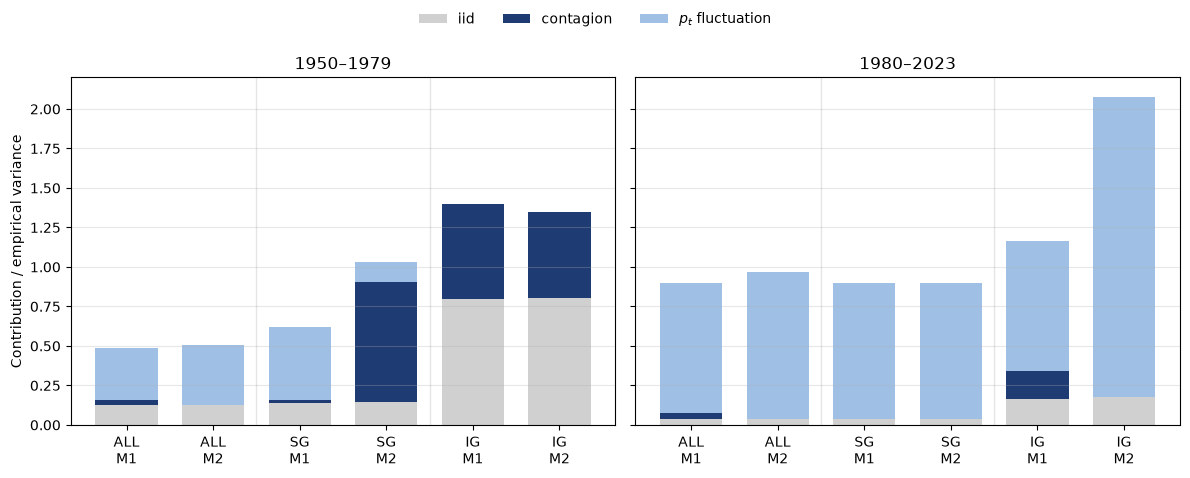

Saved: ./figure/fig_variance_decomp_two_periods.pdf


In [27]:
def prepare_plot_data(df_cmp):
    labels = []
    iid_vals = []
    inf_vals = []
    pt_vals = []

    for cls in ["ALL", "SG", "IG"]:
        for model in ["M1", "M2"]:
            sub = df_cmp[(df_cmp["class"] == cls) & (df_cmp["model"] == model)]
            assert len(sub) == 1
            labels.append(f"{cls}\n{model}")
            iid_vals.append(float(sub["Iid_over_VarData"].iloc[0]))
            inf_vals.append(float(sub["Infect_over_VarData"].iloc[0]))
            pt_vals.append(float(sub["Pt_over_VarData"].iloc[0]))

    return (
        labels,
        np.asarray(iid_vals, dtype=float),
        np.asarray(inf_vals, dtype=float),
        np.asarray(pt_vals, dtype=float),
    )


df_pre = PERIOD_RESULTS["1950_1979"]["var_compare"].copy()
df_post = PERIOD_RESULTS["1980_2023"]["var_compare"].copy()

df_pre["period"] = "1950–1979"
df_post["period"] = "1980–2023"
variance_subperiod = pd.concat([df_pre, df_post], ignore_index=True)

display(variance_subperiod.round(6))

labels_pre, iid_pre, inf_pre, pt_pre = prepare_plot_data(df_pre)
labels_post, iid_post, inf_post, pt_post = prepare_plot_data(df_post)

x = np.arange(len(labels_pre))
width = 0.72

# Canonical paper palette retained for exact figure reproduction.
c_iid = "#D0D0D0"
c_pt = "#9FBFE5"
c_inf = "#1F3B73"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

ax = axes[0]
ax.bar(x, iid_pre, width=width, color=c_iid)
ax.bar(x, inf_pre, width=width, bottom=iid_pre, color=c_inf)
ax.bar(x, pt_pre, width=width, bottom=iid_pre + inf_pre, color=c_pt)
for pos in [1.5, 3.5]:
    ax.axvline(pos, color="gray", alpha=0.2, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels_pre)
ax.set_title("1950–1979")
ax.set_ylabel("Contribution / empirical variance")
ax.set_ylim(0, 2.2)
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.bar(x, iid_post, width=width, color=c_iid, label="iid")
ax.bar(x, inf_post, width=width, bottom=iid_post, color=c_inf, label="contagion")
ax.bar(
    x, pt_post, width=width, bottom=iid_post + inf_post,
    color=c_pt, label=r"$p_t$ fluctuation"
)
for pos in [1.5, 3.5]:
    ax.axvline(pos, color="gray", alpha=0.2, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels_post)
ax.set_title("1980–2023")
ax.grid(axis="y", alpha=0.3)

handles, legend_labels = axes[1].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.92])

FIG9_PATH = FIGURE_DIR / "fig_variance_decomp_two_periods.pdf"
fig.savefig(FIG9_PATH, bbox_inches="tight")
plt.show()

print(f"Saved: {FIG9_PATH}")


## 13. Real-data Figure 9 numerical regression audit

This checks the six M1/M2 stacks in each period against the canonical decomposition used for the manuscript figure.


In [28]:
if DATA_SOURCE == "REAL":
    VAR_REFERENCE = {
        ("1950–1979", "ALL", "M1"): (0.124906, 0.030418, 0.333269),
        ("1950–1979", "ALL", "M2"): (0.125598, 0.000000, 0.383319),
        ("1950–1979", "SG",  "M1"): (0.141826, 0.016104, 0.460598),
        ("1950–1979", "SG",  "M2"): (0.148114, 0.754583, 0.128940),
        ("1950–1979", "IG",  "M1"): (0.798208, 0.602151, 0.000000),
        ("1950–1979", "IG",  "M2"): (0.805997, 0.543939, 0.000000),
        ("1980–2023", "ALL", "M1"): (0.034952, 0.042365, 0.819943),
        ("1980–2023", "ALL", "M2"): (0.034923, 0.000000, 0.935855),
        ("1980–2023", "SG",  "M1"): (0.036475, 0.000000, 0.862465),
        ("1980–2023", "SG",  "M2"): (0.036475, 0.000000, 0.862465),
        ("1980–2023", "IG",  "M1"): (0.167083, 0.176666, 0.820373),
        ("1980–2023", "IG",  "M2"): (0.179717, 0.000000, 1.896940),
    }

    var_audit_rows = []
    for _, r in variance_subperiod.iterrows():
        key = (str(r["period"]), str(r["class"]), str(r["model"]))
        ref = VAR_REFERENCE[key]
        obs = (
            float(r["Iid_over_VarData"]),
            float(r["Infect_over_VarData"]),
            float(r["Pt_over_VarData"]),
        )
        deltas = np.asarray(obs) - np.asarray(ref)
        var_audit_rows.append({
            "period": key[0], "class": key[1], "model": key[2],
            "max_abs_delta": float(np.max(np.abs(deltas))),
        })

    var_audit = pd.DataFrame(var_audit_rows)
    display(var_audit)
    max_var_delta = float(var_audit["max_abs_delta"].max())
    print(f"Maximum Figure 9 component difference: {max_var_delta:.6g}")
    assert max_var_delta < 5e-4
    print("Figure 9 numerical audit: PASS")
else:
    var_audit = pd.DataFrame()
    print("Synthetic data: Figure 9 manuscript-value audit skipped.")


,period,class,model,max_abs_delta
0,1950–1979,ALL,M1,3.609103e-07
1,1950–1979,SG,M1,4.147643e-07
2,1950–1979,IG,M1,2.132464e-07
3,1950–1979,ALL,M2,3.944300e-07
4,1950–1979,SG,M2,4.743290e-07
5,1950–1979,IG,M2,2.738699e-07
6,1980–2023,ALL,M1,4.431055e-07
7,1980–2023,SG,M1,3.937000e-07
8,1980–2023,IG,M1,4.913637e-07
9,1980–2023,ALL,M2,4.192208e-07


Maximum Figure 9 component difference: 3.18406e-06
Figure 9 numerical audit: PASS


## 14. Export subperiod outputs


In [29]:
# Detailed fit outputs.
static_details = []
pn_details = []

for pname in ["1950_1979", "1980_2023"]:
    a = PERIOD_RESULTS[pname]["static_fit_table"].copy()
    a.insert(0, "period", PERIOD_LABEL[pname])
    static_details.append(a)

    b = PERIOD_RESULTS[pname]["pn_fit_table"].copy()
    b.insert(0, "period", PERIOD_LABEL[pname])
    pn_details.append(b)

static_details = pd.concat(static_details, ignore_index=True)
pn_details = pd.concat(pn_details, ignore_index=True)

outputs = {
    "subperiod_static_fit_details.csv": static_details,
    "subperiod_environmental_fit_details.csv": pn_details,
    "table_x_static_subperiod.csv": table_x,
    "table_xi_subperiod_nll.csv": table_xi,
    "subperiod_variance_decomposition.csv": variance_subperiod,
    "subperiod_boundary_audit.csv": boundary_audit,
}

if DATA_SOURCE == "REAL":
    outputs["subperiod_nll_regression_audit.csv"] = nll_audit
    outputs["subperiod_variance_regression_audit.csv"] = var_audit

for name, frame in outputs.items():
    path = PDATA_DIR / name
    frame.to_csv(path, index=False)
    print("Saved:", path)


Saved: ./pdata/subperiod_static_fit_details.csv
Saved: ./pdata/subperiod_environmental_fit_details.csv
Saved: ./pdata/table_x_static_subperiod.csv
Saved: ./pdata/table_xi_subperiod_nll.csv
Saved: ./pdata/subperiod_variance_decomposition.csv
Saved: ./pdata/subperiod_boundary_audit.csv
Saved: ./pdata/subperiod_nll_regression_audit.csv
Saved: ./pdata/subperiod_variance_regression_audit.csv


## Completion criteria

For the authorized real dataset, a successful run should satisfy all of the following:

- static Vasicek and direct M0 likelihoods agree numerically in all six class-period combinations;
- corrected late-period values are approximately ALL 214.61, SG 208.75, IG 84.71 for Vasicek/M0;
- Table XI reproduces early SG M2 = 55.96 and late ALL/IG M1 = 212.73 / 83.42;
- M2 boundary structure matches the canonical subperiod analysis;
- the Figure 9 component audit passes;
- `figure/fig_variance_decomp_two_periods.pdf` is regenerated.

After 03F is verified, the scientific notebook split is complete and the shared-function refactor can be delegated to AntiGravity with numerical regression checks before and after modularization.
